Héctor Rodríguez Lozano - Desenvolupament al nigul/CIDE/25-26

In [32]:
# Descomentar para actualizar librerias
# Si se actualiza alguna libreria hay que reiniciar el notebook
# !pip install pandas --upgrade --user --quiet
# !pip install numpy --upgrade --user --quiet
# !pip install scipy --upgrade --user --quiet
# !pip install scikit-learn --upgrade --user --quiet
!pip install missingno --upgrade --user --quiet

In [33]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

In [51]:
from sklearn import datasets

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# sns.set()
import pandas as pd

from sklearn import set_config
import warnings

set_config(display='text')
warnings.filterwarnings('ignore')
pd.set_option('display.precision', 3)

from mpl_toolkits.mplot3d import Axes3D

from sklearn.decomposition import PCA
from sklearn.manifold import LocallyLinearEmbedding, TSNE
from sklearn.preprocessing import StandardScaler


# Ejercicio práctico de visualización

En este ejercicio trabajaremos con el conjunto de datos preprocesado en la primera sesion de laboratorio.

Encontraréis los datos preprocesados de Titanic entre el material de esta sesion (conjunto de entrenamiento), o podeis coger los datos que grabasteis en la sesión pasada.



Debéis aplicar los siguientes pasos:
- [ ] Aplicar PCA
- [ ] Gráfica de la varianza explicada por cada componente de PCA
- [ ] Representar los pesos de los componentes
- [ ] Visualizar los datos con PCA en 2/3D
- [ ] Aplicar LLE y visualizar los datos en 2/3D
- [ ] Aplicar t-SNE y visualizar los datos en 2/3D


## LOAD FILE TITANIC_TRAIN

In [35]:
titanic = pd.read_csv("./titanic_train.csv", header=0, delimiter=',')
titanic.head()

,survived,pclass,sex,sibsp,parch,embarked_Q,embarked_S,iage,adult,fare_yj
0,1,0.5,0,0.000,0.111,0.0,1.0,0.176,0,0.572
1,1,0.5,0,0.125,0.111,0.0,1.0,0.054,0,0.597
2,1,0.5,0,0.125,0.000,0.0,0.0,0.405,1,0.520
3,0,1.0,1,0.000,0.000,1.0,0.0,0.500,1,0.430
4,1,1.0,0,0.000,0.000,1.0,0.0,0.297,1,0.430


##ESTANDARIZACIÓN DE DATOS

In [36]:
data_columns = ['pclass','sex','sibsp','parch','embarked_Q','embarked_S','iage','adult','fare_yj']
titanic[data_columns].describe()

,pclass,sex,sibsp,parch,embarked_Q,embarked_S,iage,adult,fare_yj
count,916.000,916.000,916.000,916.000,916.000,916.000,916.000,916.000,916.000
mean,0.646,0.634,0.067,0.041,0.091,0.714,0.406,0.909,0.556
std,0.421,0.482,0.141,0.093,0.287,0.452,0.173,0.287,0.153
min,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,0.000,0.000,0.000,0.000,0.000,0.000,0.311,1.000,0.433
50%,1.000,1.000,0.000,0.000,0.000,1.000,0.378,1.000,0.526
75%,1.000,1.000,0.125,0.000,0.000,1.000,0.500,1.000,0.642
max,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000


In [37]:
titanic_standarized = titanic.copy()
titanic_standarized[data_columns] = StandardScaler().fit_transform(titanic[data_columns])
titanic_standarized.describe().T

,count,mean,std,min,25%,50%,75%,max
survived,916.0,3.854e-01,0.487,0.000,0.000,0.000,1.000,1.000
pclass,916.0,1.164e-16,1.001,-1.535,-1.535,0.840,0.840,0.840
sex,916.0,-2.909e-17,1.001,-1.317,-1.317,0.759,0.759,0.759
sibsp,916.0,-9.696e-18,1.001,-0.473,-0.473,-0.473,0.415,6.636
parch,916.0,7.466e-17,1.001,-0.443,-0.443,-0.443,-0.443,10.309
embarked_Q,916.0,-9.696e-18,1.001,-0.316,-0.316,-0.316,-0.316,3.168
embarked_S,916.0,-7.272e-17,1.001,-1.580,-1.580,0.633,0.633,0.633
iage,916.0,5.042e-17,1.001,-2.347,-0.552,-0.162,0.540,3.427
adult,916.0,4.654e-17,1.001,-3.168,0.316,0.316,0.316,0.316
fare_yj,916.0,-3.491e-16,1.001,-3.624,-0.799,-0.190,0.565,2.899


##1. Aplicación PCA y  Gráfica de la varianza



In [38]:
myPCA = PCA().fit(titanic_standarized[data_columns]);

print(myPCA.explained_variance_ratio_)
print(myPCA.explained_variance_ratio_.cumsum())

[0.23685755 0.22658984 0.16851627 0.09881596 0.09262479 0.06429483
 0.04996741 0.03902445 0.0233089 ]
[0.23685755 0.46344739 0.63196366 0.73077962 0.82340441 0.88769924
 0.93766665 0.9766911  1.        ]


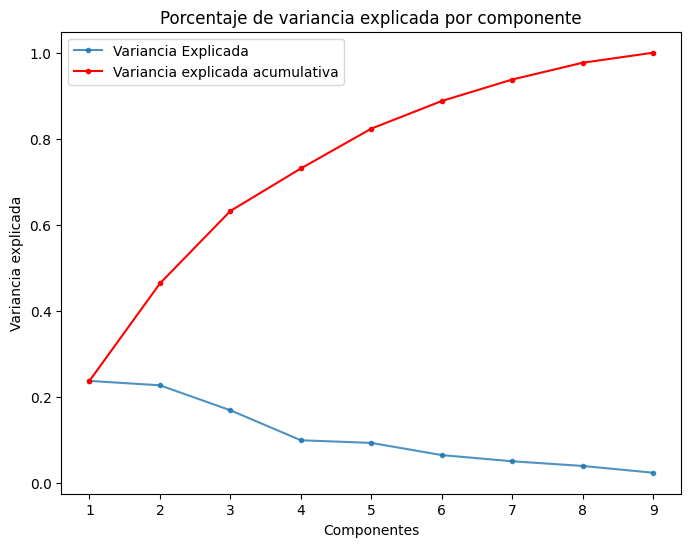

In [39]:
fig = plt.figure(figsize=(8,6));
plt.plot(range(1,len(myPCA.explained_variance_ratio_ )+1),myPCA.explained_variance_ratio_ ,alpha=0.8,marker='.',label="Variancia Explicada");
y_label = plt.ylabel('Variancia explicada');
x_label = plt.xlabel('Componentes');
plt.plot(range(1,len(myPCA.explained_variance_ratio_ )+1),
         np.cumsum(myPCA.explained_variance_ratio_),
         c='red',marker='.',
         label="Variancia explicada acumulativa");
plt.legend();
plt.title('Porcentaje de variancia explicada por componente');

PCA no es una buena eleccion ya que se requiere almenos con dos elementos llegar al 90% para leer el dataset y en este caso en concreto la lectura con dos elementos es muy pobre.

## 2. Representación de los pesos de los componentes

Podemos visualizar también los pesos que le asigna el PCA a cada componente

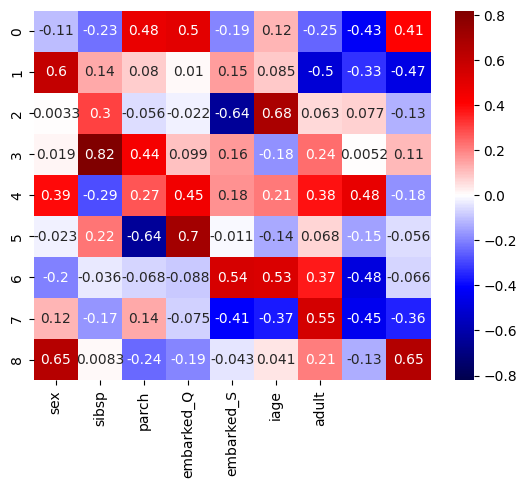

In [43]:
sns.heatmap(myPCA.components_, cmap='seismic',
            xticklabels=list(titanic.columns[2:-1]),
            vmin=-np.max(np.abs(myPCA.components_)),
            vmax=np.max(np.abs(myPCA.components_)),
            annot=True);

El mapa de calor muestra cuánto aporta cada característica original a cada componente del PCA. Esto ayuda a entender qué representa cada componente


##3. Visualización de los datos con PCA en 2/3D


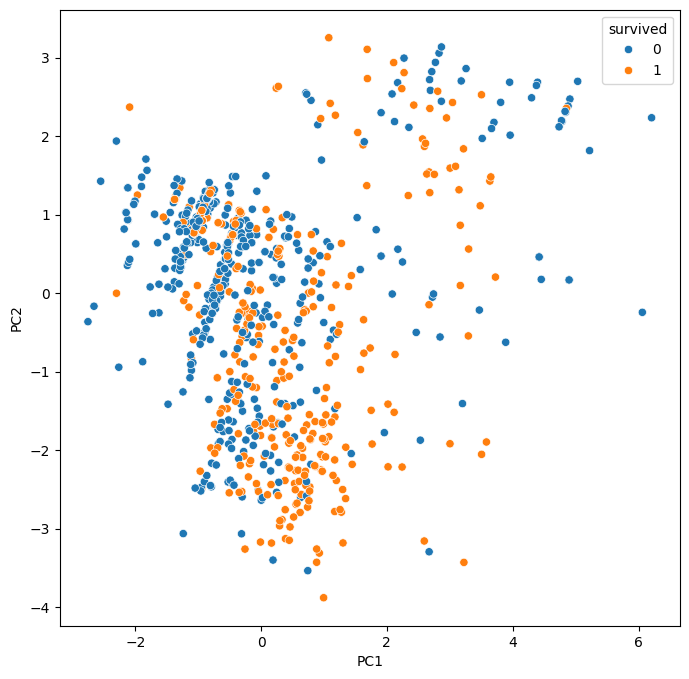

In [47]:
transformed_titanic = myPCA.transform(titanic_standarized[data_columns])
titanic_standarized[['PC1','PC2', 'PC3']] = transformed_titanic[:,:3]
fig = plt.figure(figsize=(8,8))
_ = sns.scatterplot(x='PC1', y='PC2', hue='survived', data=titanic_standarized)

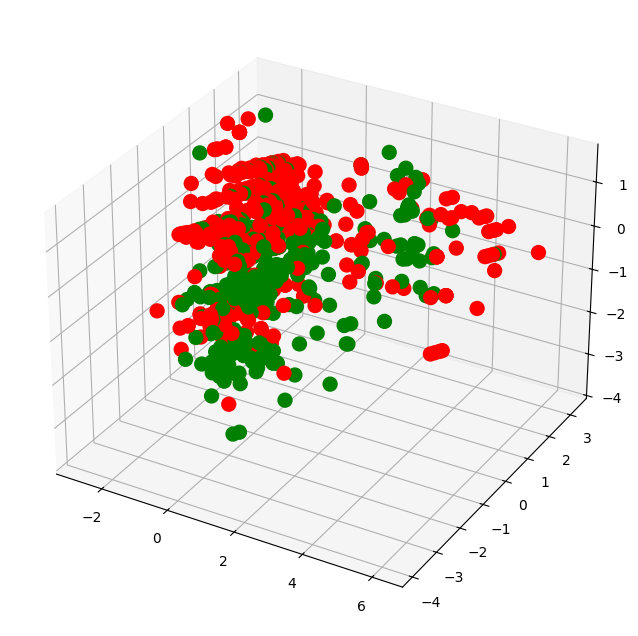

In [52]:
colors_survived = {0: 'red', 1: 'green'}

fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111, projection='3d')

plt.scatter(titanic_standarized.PC1,
            titanic_standarized.PC2,
            zs=titanic_standarized.PC3,
            depthshade=False,
            c=titanic_standarized['survived'].map(colors_survived), s=100);

Usamos la técnica PCA para simplificar nuestros datos y poder dibujarlos. Tenemos gráficos en 2 y 3 dimensiones para ver cómo se agrupan los pasajeros según si sobrevivieron o no, usando esas nuevas 'direcciones' que nos da PCA.


## 4. Aplicación de LLE y visualización de los datos en 2/3D

In [54]:
from sklearn.preprocessing import MinMaxScaler

titanic_min_max = titanic_standarized.copy()
titanic_min_max[data_columns] = MinMaxScaler().fit_transform(titanic_standarized[data_columns])
titanic_min_max.describe()

,survived,pclass,sex,sibsp,parch,embarked_Q,embarked_S,iage,adult,fare_yj,PC1,PC2,PC3,TSNE1,TSNE2,TSNE3
count,916.000,916.000,916.000,916.000,916.000,916.000,916.000,916.000,916.000,916.000,9.160e+02,9.160e+02,9.160e+02,916.000,916.000,916.000
mean,0.385,0.646,0.634,0.067,0.041,0.091,0.714,0.406,0.909,0.556,-7.757e-18,-2.909e-17,-8.533e-17,-0.345,0.207,0.900
std,0.487,0.421,0.482,0.141,0.093,0.287,0.452,0.173,0.287,0.153,1.461e+00,1.429e+00,1.232e+00,11.425,9.944,12.075
min,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,-2.751e+00,-3.881e+00,-3.696e+00,-21.157,-23.164,-22.648
25%,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.311,1.000,0.433,-9.577e-01,-1.080e+00,-5.201e-01,-10.029,-5.590,-8.538
50%,0.000,1.000,1.000,0.000,0.000,0.000,1.000,0.378,1.000,0.526,-3.940e-01,3.899e-01,3.433e-01,0.453,1.383,0.279
75%,1.000,1.000,1.000,0.125,0.000,0.000,1.000,0.500,1.000,0.642,6.169e-01,9.660e-01,9.634e-01,7.687,6.047,6.339
max,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,6.208e+00,3.252e+00,1.476e+00,25.453,21.207,29.256


Reconstruction error: -6.603155455606635e-18


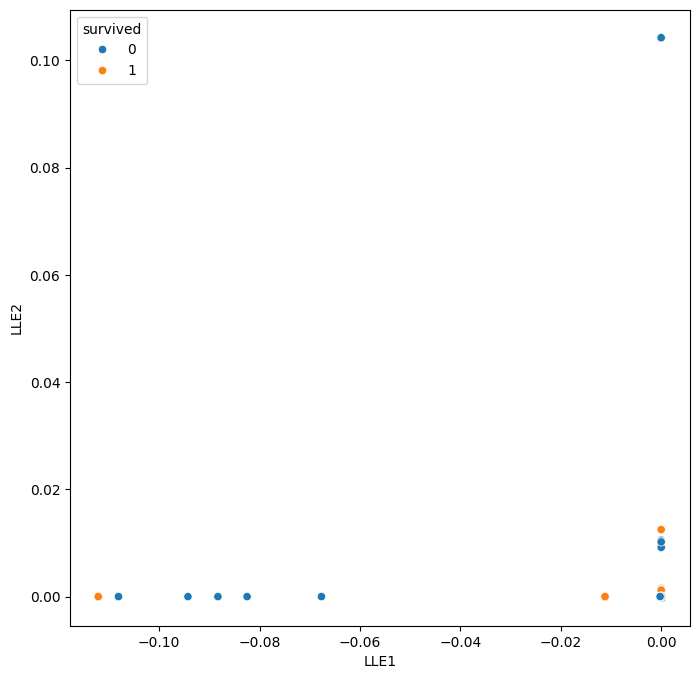

In [56]:
from sklearn.manifold import LocallyLinearEmbedding

lle = LocallyLinearEmbedding(n_components=2, n_neighbors=15, random_state=42)
lle_transformed = lle.fit_transform(titanic_min_max[data_columns])

print('Reconstruction error:', lle.reconstruction_error_)
titanic_min_max[['LLE1','LLE2']]=lle_transformed
fig = plt.figure(figsize=(8,8))
sns.scatterplot(x='LLE1', y='LLE2', hue='survived', data=titanic_min_max);

Reconstruction error: -2.4872820065360644e-17


Text(0.5, 0.92, 'LLE de Titanic (3D)')

Text(0.5, 0, 'LLE1')

Text(0.5, 0.5, 'LLE2')

Text(0.5, 0, 'LLE3')

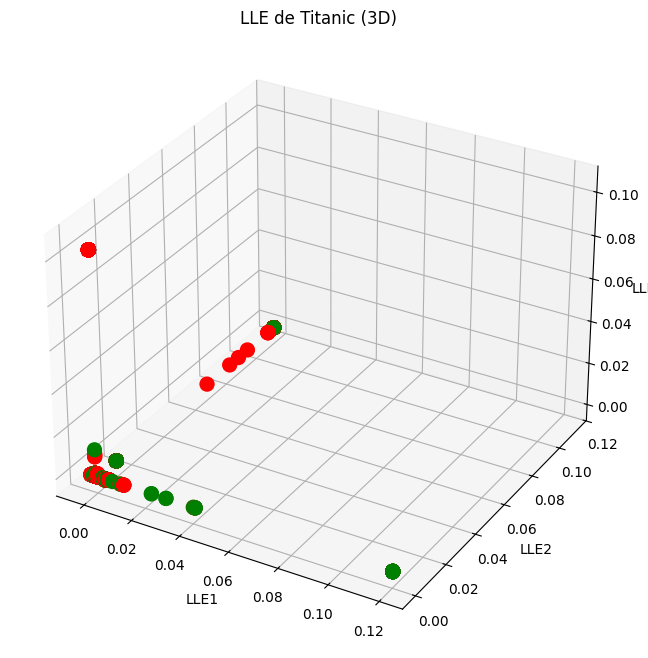

In [58]:
lle = LocallyLinearEmbedding(n_components=3, n_neighbors=15, random_state=42)
lle_transformed_3d = lle.fit_transform(titanic_min_max[data_columns])

print('Reconstruction error:', lle.reconstruction_error_)
titanic_min_max[['LLE1_3D','LLE2_3D', 'LLE3_3D']]=lle_transformed_3d
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111, projection='3d')

plt.scatter(titanic_min_max.LLE1_3D,
            titanic_min_max.LLE2_3D,
            zs=titanic_min_max.LLE3_3D,
            depthshade=False,
            c=titanic_min_max['survived'].map(colors_survived), s=100);

ax.set_title('LLE de Titanic (3D)')
ax.set_xlabel('LLE1')
ax.set_ylabel('LLE2')
ax.set_zlabel('LLE3')
plt.show()

In [61]:
import plotly.express as px

fig = px.scatter_3d(titanic_min_max, x='LLE1_3D', y='LLE2_3D', z='LLE3_3D',
              color='survived', title='LLE de Titanic (3D)')
fig.show()

Se aplica la técnica de Embedding Localmente Lineal (LLE) para reducir la dimensionalidad de los datos estandarizados del Titanic. El objetivo principal de LLE es preservar la estructura geométrica local de los datos en un espacio de menor dimensión, a diferencia de PCA que se enfoca en la varianza global. Los gráficos resultantes en 2D y 3D nos permiten observar cómo los pasajeros se agrupan en función de las características originales, al colorear los puntos según la supervivencia, podemos explorar si LLE revela patrones de agrupamiento distintivos entre los sobrevivientes y los no sobrevivientes que no eran evidentes con PCA. Esto nos ayuda a identificar si las características que LLE descubre tienen una correlación más clara con el destino de los pasajeros

##5. Aplicación de t-SNE y visualización de los datos en 2/3D

<Axes: xlabel='TSNE1', ylabel='TSNE2'>

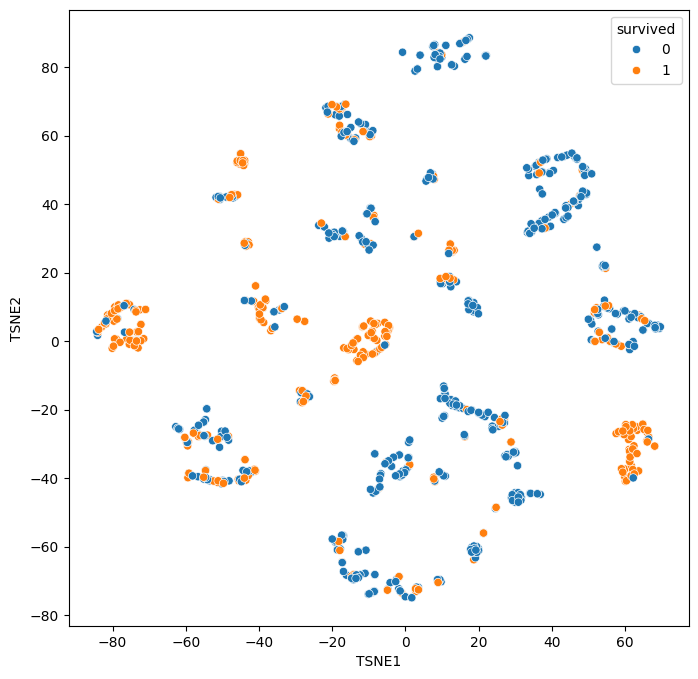

In [63]:
from sklearn.manifold import TSNE

titanic_tsne = TSNE(n_components=2, perplexity=10,n_iter=2000, init='random').fit_transform(titanic_min_max[data_columns])
titanic_min_max[['TSNE1','TSNE2']]=titanic_tsne
fig = plt.figure(figsize=(8,8))
sns.scatterplot(x='TSNE1', y='TSNE2', hue='survived', data=titanic_min_max)

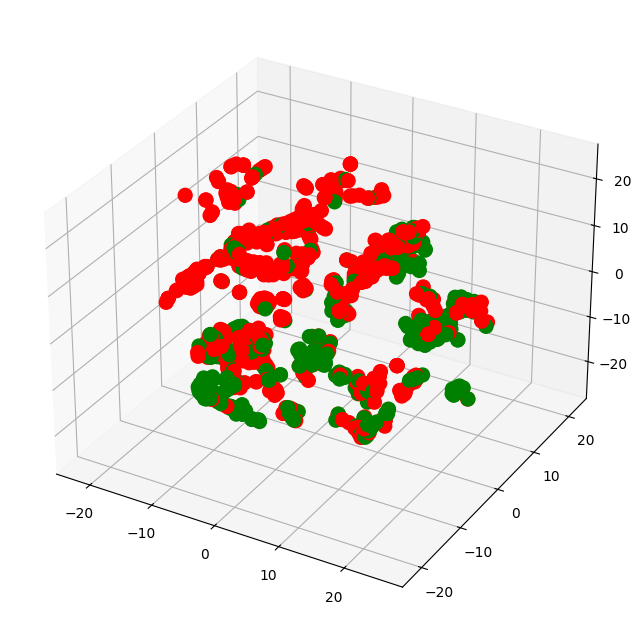

In [70]:
tsne_3d = TSNE(n_components=3, perplexity=10, n_iter=2000, init='random', random_state=42).fit_transform(titanic_min_max[data_columns])
titanic_min_max[['TSNE1_3D','TSNE2_3D','TSNE3_3D']] = tsne_3d
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111, projection='3d')

plt.scatter(titanic_min_max.TSNE1_3D,
            titanic_min_max.TSNE2_3D,
            zs=titanic_min_max.TSNE3_3D,
            depthshade=False,
            c=titanic_min_max['survived'].map(colors_survived), s=100);

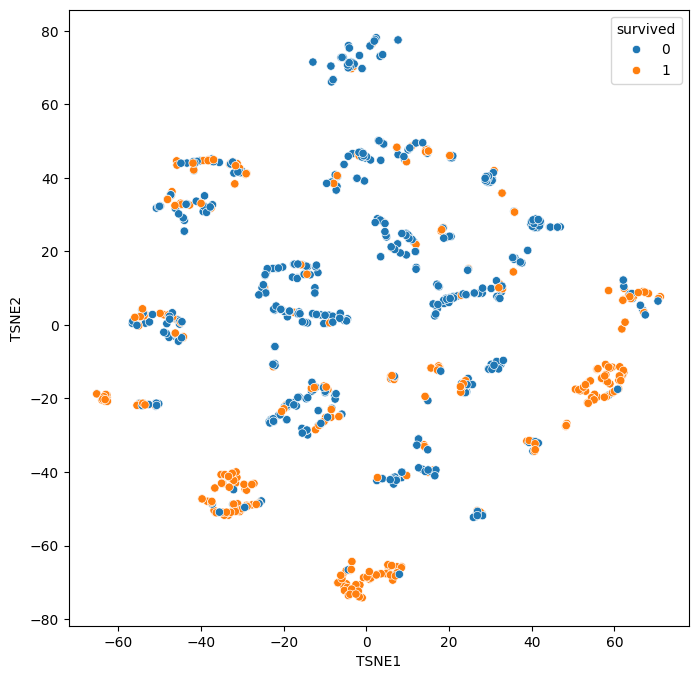

In [72]:
titanic_tsne = TSNE(n_components=2, perplexity=10,n_iter=1000, init='random').fit_transform(titanic_min_max[data_columns])
titanic_min_max[['TSNE1','TSNE2',]]=titanic_tsne

fig = plt.figure(figsize=(8,8))
sns.scatterplot(x='TSNE1', y='TSNE2', hue='survived', data=titanic_min_max);

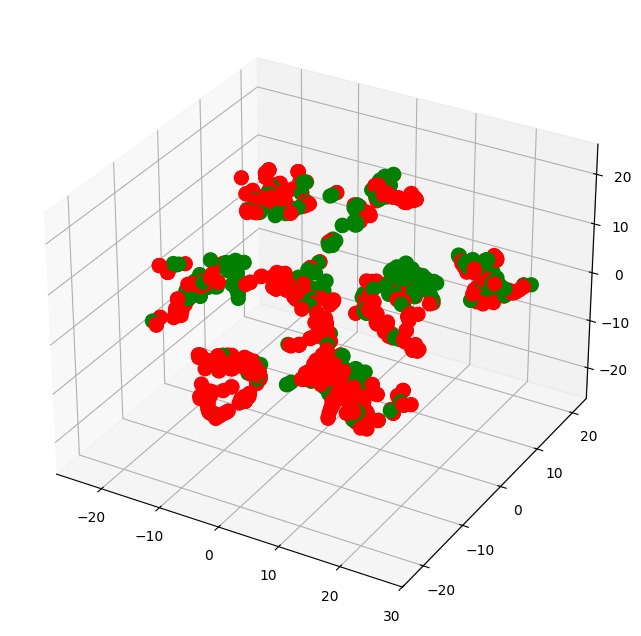

In [77]:
titanic_tsne = TSNE(n_components=3, perplexity=10,n_iter=2000, init='random').fit_transform(titanic_min_max[data_columns])
titanic_min_max[['TSNE1_3D','TSNE2_3D','TSNE3_3D']]=titanic_tsne

fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111, projection='3d')
plt.scatter(titanic_min_max.TSNE1_3D,
            titanic_min_max.TSNE2_3D,
            zs=titanic_min_max.TSNE3_3D,
            depthshade=False,
            c=titanic_min_max['survived'].map(colors_survived), s=100);

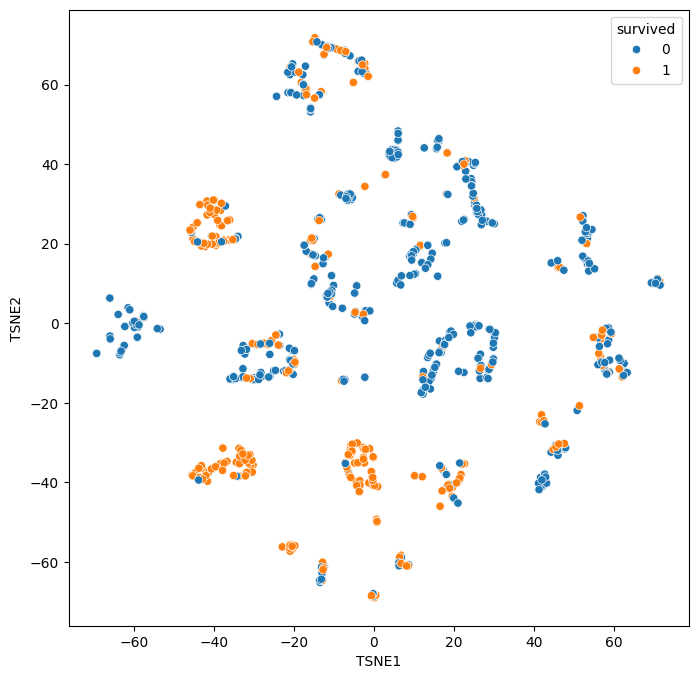

In [79]:
titanic_tsne = TSNE(n_components=2, perplexity=10,n_iter=1000, init='random').fit_transform(titanic_min_max[data_columns])
titanic_min_max[['TSNE1','TSNE2']]=titanic_tsne
fig = plt.figure(figsize=(8,8))
sns.scatterplot(x='TSNE1', y='TSNE2', hue='survived', data=titanic_min_max);

Text(0.5, 0.92, 't-SNE de Titanic (3D)')

Text(0.5, 0, 'TSNE1_3D')

Text(0.5, 0.5, 'TSNE2_3D')

Text(0.5, 0, 'TSNE3_3D')

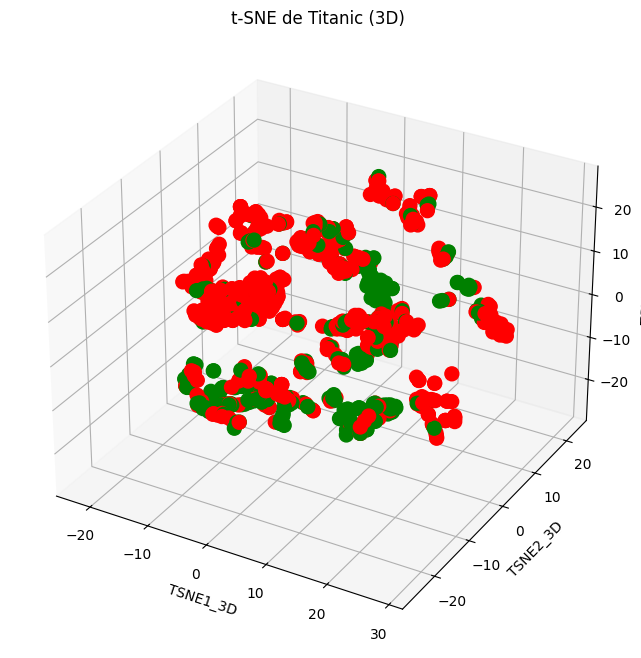

In [81]:
titanic_tsne_3d = TSNE(n_components=3, perplexity=10,n_iter=3000, init='random').fit_transform(titanic_min_max[data_columns])
titanic_min_max[['TSNE1_3D','TSNE2_3D','TSNE3_3D']]=titanic_tsne_3d

fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111, projection='3d')

plt.scatter(titanic_min_max.TSNE1_3D,
            titanic_min_max.TSNE2_3D,
            zs=titanic_min_max.TSNE3_3D,
            depthshade=False,
            c=titanic_min_max['survived'].map(colors_survived), s=100);

<Axes: xlabel='TSNE1', ylabel='TSNE2'>

Text(0.5, 1.0, "t-SNE de Titanic (2D) - init='pca'")

Text(0.5, 0, 'TSNE1')

Text(0, 0.5, 'TSNE2')

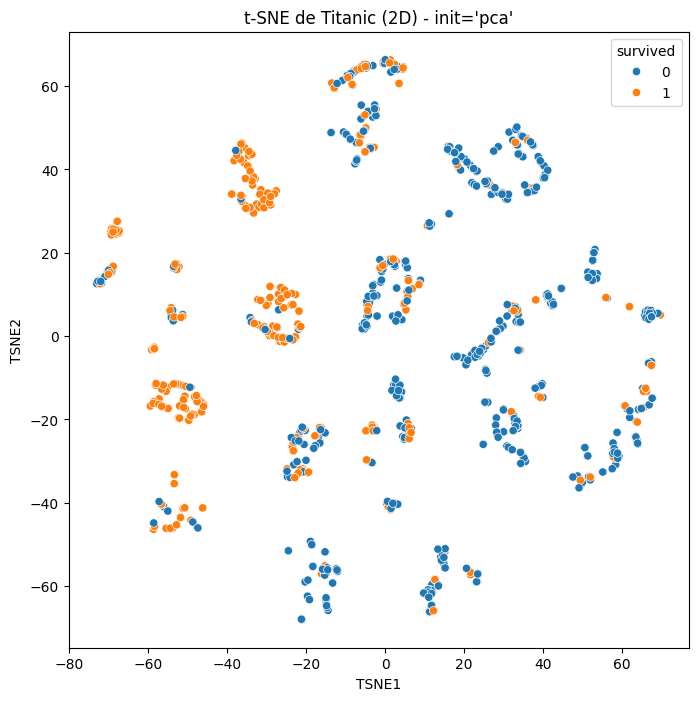

In [83]:
titanic_tsne = TSNE(n_components=2, perplexity=10,n_iter=1000, init='pca').fit_transform(titanic_min_max[data_columns])
titanic_min_max[['TSNE1','TSNE2',]]=titanic_tsne
fig = plt.figure(figsize=(8,8))
sns.scatterplot(x='TSNE1', y='TSNE2', hue='survived', data=titanic_min_max)

Text(0.5, 0.92, "t-SNE de Titanic (3D) - init='pca'")

Text(0.5, 0, 'TSNE1')

Text(0.5, 0.5, 'TSNE2')

Text(0.5, 0, 'TSNE3')

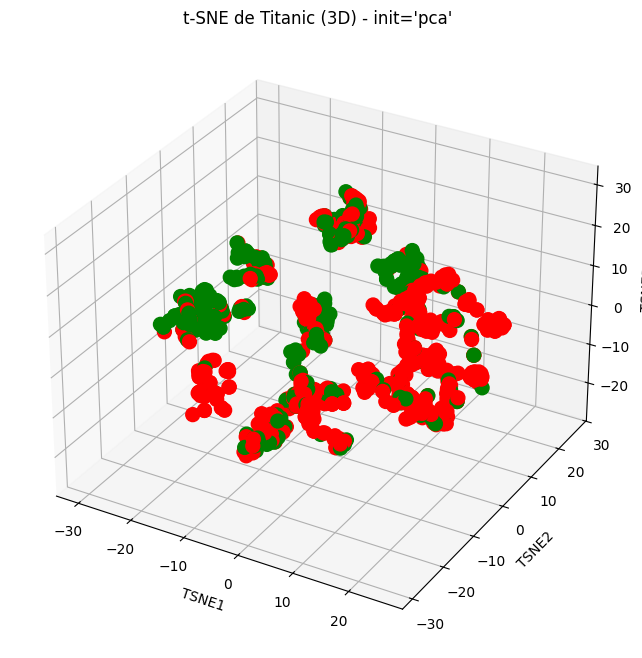

In [85]:
titanic_tsne_3d = TSNE(n_components=3, perplexity=12,n_iter=4000, init='pca').fit_transform(titanic_min_max[data_columns])
titanic_min_max[['TSNE1','TSNE2','TSNE3']]=titanic_tsne_3d

fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111, projection='3d')

plt.scatter(titanic_min_max.TSNE1,
            titanic_min_max.TSNE2,
            zs=titanic_min_max.TSNE3,
            depthshade=False,
            c=titanic_min_max['survived'].map(colors_survived), s=100);

In [89]:
fig = px.scatter_3d(titanic_min_max, x='TSNE1_3D', y='TSNE2_3D', z='TSNE3_3D',
              color='survived')
fig.show()

Se plica la técnica t-Distributed Stochastic Neighbor Embedding (t-SNE). Esta es una técnica de reducción de dimensionalidad no lineal particularmente efectiva para visualizar conjuntos de datos de alta dimensión, proyectándolos en un espacio de dos o tres dimensiones mientras se preservan las agrupaciones locales de los puntos. A diferencia de PCA y LLE, t-SNE se centra en mantener las distancias entre puntos similares y no similares, buscando revelar estructuras o clusters en los datos que otras técnicas podrían pasar por alto. Al visualizar los datos en 2D y 3D, y colorear los puntos, podemos observar la formación de conglomerados y evaluar si t-SNE es capaz de separar de manera más clara a los pasajeros que sobrevivieron de los que no, basándose en las características del dataset del Titanic

